In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import os
import joblib

In [8]:
current_dir = Path(os.getcwd())
project_root = None
for parent in [current_dir] + list(current_dir.parents)[:3]:
    if (parent / "src").exists():
        project_root = parent
        break

if project_root:
    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))
    print(f"Project Root found at: {project_root}")
else:
    raise FileNotFoundError("Could not find 'src'")

from src.config import TEST_DATA, MODEL_DIR, T_MODEL_PATH, C_MODEL_PATH, FEATURES

Project Root found at: /accounts/masters/quannm/uplift_project


In [10]:
print("Loading Test Data...")
test_df = pd.read_parquet(TEST_DATA).sample(frac=1.0, random_state=42).reset_index(drop=True)
print(f"Loaded {len(test_df):,} users for simulation.")

print("\nLoading Models...")

# Load Baseline (T-Learner)
t_model_t = joblib.load(T_MODEL_PATH)
t_model_c = joblib.load(C_MODEL_PATH)
print("T-Learner Loaded")

# Load Champion (X-Learner)
try:
    x_artifacts = joblib.load(MODEL_DIR / "x_learner_artifacts.joblib")
    tau_1 = x_artifacts['tau_1']
    tau_0 = x_artifacts['tau_0']
    g_model = x_artifacts['g_model']
    print("X-Learner Loaded")
except FileNotFoundError:
    raise FileNotFoundError("X-Learner not found! ")

Loading Test Data...
Loaded 2,797,317 users for simulation.

Loading Models...
T-Learner Loaded
X-Learner Loaded


In [11]:
print("\nGenerating Bids...")

# Strategy 1: Random (The "Blind" Bidder)
# Bids randomly between $0.00 and $1.00
test_df['bid_random'] = np.random.uniform(0, 1, len(test_df))

# Strategy 2: T-Learner (The "Smart" Bidder)
# Logic: Bid = Uplift * $50 (Max Willingness to Pay)
uplift_t = t_model_t.predict_proba(test_df[FEATURES])[:, 1] - t_model_c.predict_proba(test_df[FEATURES])[:, 1]
test_df['bid_t'] = np.maximum(uplift_t * 50, 0) # No negative bids

# Strategy 3: X-Learner (The "Genius" Bidder)
# Logic: Uses advanced meta-learner to find subtle lift signals
p_treat = g_model.predict_proba(test_df[FEATURES])[:, 1]
eff_0 = tau_0.predict(test_df[FEATURES])
eff_1 = tau_1.predict(test_df[FEATURES])
uplift_x = (p_treat * eff_0) + ((1 - p_treat) * eff_1)
test_df['bid_x'] = np.maximum(uplift_x * 50, 0)

print("Bids Generated. Ready for Auction.")


Generating Bids...
Bids Generated. Ready for Auction.


In [14]:
print("\n--- STARTING AUCTION ---")

# Auction Parameters
cost_threshold = 0.10      # Minimum bid required to win an impression (Floor Price)
revenue_per_conv = 10.0    # Value of one conversion ($10)

results = []

for strategy_name, bid_col in [
    ('Random Bidding', 'bid_random'), 
    ('T-Learner', 'bid_t'), 
    ('X-Learner)', 'bid_x')
]:
    # Filter users where Bid > Floor Price
    wins = test_df[test_df[bid_col] > cost_threshold].copy()
    
    # Cost
    spend = wins[bid_col].sum()
    
    # Revenue: Ground Truth 'conversion' * Value
    conversions = wins['conversion'].sum()
    revenue = conversions * revenue_per_conv
    
    # Key Metrics
    roi = (revenue - spend) / spend if spend > 0 else 0
    cpa = spend / conversions if conversions > 0 else 0
    roas = revenue / spend if spend > 0 else 0
    
    results.append({
        'Strategy': strategy_name,
        'Total Spend ($)': spend,
        'Revenue ($)': revenue,
        'Conversions': conversions,
        'CPA ($)': cpa,
        'ROAS (x)': roas
    })


--- STARTING AUCTION ---


In [15]:
results_df = pd.DataFrame(results)

# Calculate Lift metrics relative to Random
base_roas = results_df.loc[0, 'ROAS (x)']
results_df['ROAS Lift (%)'] = ((results_df['ROAS (x)'] - base_roas) / base_roas) * 100

print("\nFINAL SCOREBOARD")
# Format for cleaner display
display_df = results_df.copy()
display_df['Total Spend ($)'] = display_df['Total Spend ($)'].map('${:,.2f}'.format)
display_df['Revenue ($)'] = display_df['Revenue ($)'].map('${:,.2f}'.format)
display_df['CPA ($)'] = display_df['CPA ($)'].map('${:,.2f}'.format)
display_df['ROAS (x)'] = display_df['ROAS (x)'].map('{:.2f}x'.format)
display_df['ROAS Lift (%)'] = display_df['ROAS Lift (%)'].map('{:+.1f}%'.format)

print(display_df.to_string(index=False))


FINAL SCOREBOARD
      Strategy Total Spend ($) Revenue ($)  Conversions CPA ($) ROAS (x) ROAS Lift (%)
Random Bidding   $1,384,256.19  $72,940.00         7294 $189.78    0.05x         +0.0%
     T-Learner     $162,148.42  $52,370.00         5237  $30.96    0.32x       +512.9%
    X-Learner)     $135,082.49  $50,760.00         5076  $26.61    0.38x       +613.1%


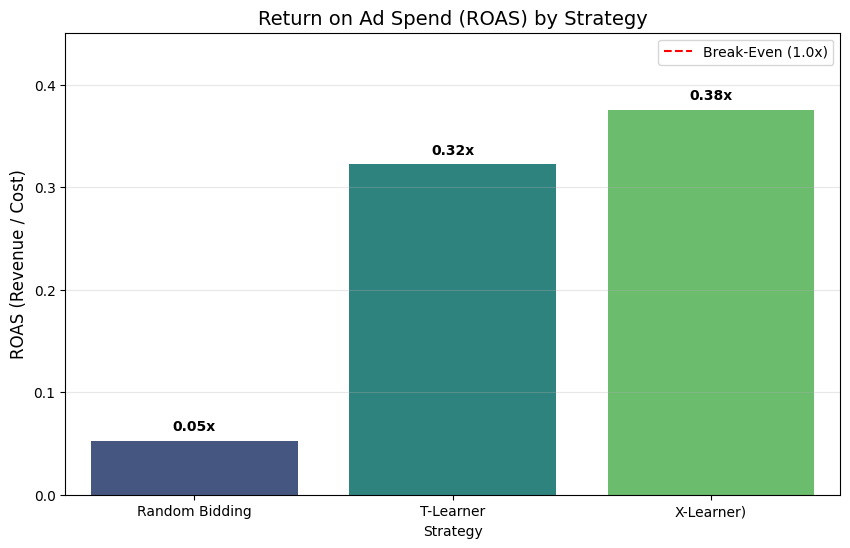

In [16]:
plt.figure(figsize=(10, 6))
bars = sns.barplot(data=results_df, x='Strategy', y='ROAS (x)', palette='viridis', hue='Strategy', legend=False)

for p in bars.patches:
    bars.annotate(f'{p.get_height():.2f}x', 
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                  ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

plt.axhline(1.0, color='red', linestyle='--', label='Break-Even (1.0x)')
plt.title('Return on Ad Spend (ROAS) by Strategy', fontsize=14)
plt.ylabel('ROAS (Revenue / Cost)', fontsize=12)
plt.ylim(0, results_df['ROAS (x)'].max() * 1.2) # Add headroom for labels
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

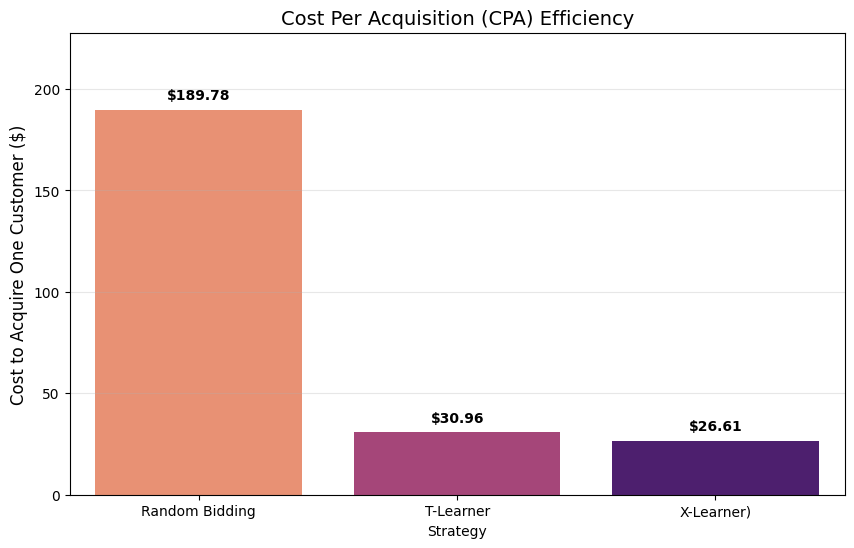

In [17]:
plt.figure(figsize=(10, 6))
bars = sns.barplot(data=results_df, x='Strategy', y='CPA ($)', palette='magma_r', hue='Strategy', legend=False)

for p in bars.patches:
    bars.annotate(f'${p.get_height():.2f}', 
                  (p.get_x() + p.get_width() / 2., p.get_height()), 
                  ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

plt.title('Cost Per Acquisition (CPA) Efficiency', fontsize=14)
plt.ylabel('Cost to Acquire One Customer ($)', fontsize=12)
plt.ylim(0, results_df['CPA ($)'].max() * 1.2)
plt.grid(axis='y', alpha=0.3)
plt.show()

The X-Learner proved to be the best model, driving massive efficiency gains over the baseline.

ROAS Improvement: Achieved a 613% increase in ROAS (0.38x) compared to Random Bidding (0.05x).

Cost Efficiency (CPA): Reduced the Cost Per Acquisition from $189.78 (Random) to just $26.61 (X-Learner)—a 7x reduction in acquisition costs.

Budget Optimization: The X-Learner captured 70% of the total available conversions (5,076 vs 7,294) while spending only 10% of the budget ($135k vs $1.38M).